In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/sudan.csv",low_memory=False
)
df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
0,2015,1,25.18,35.55,16.14,19.41,0.0,31.87,3.46,5.12,96.54,6.08
1,2015,2,23.92,34.14,15.81,18.33,0.0,23.83,4.24,5.10,96.67,4.31
2,2015,3,22.73,31.64,15.09,16.55,0.0,38.21,5.01,6.24,96.77,6.42
3,2015,4,19.15,27.35,12.88,14.47,0.0,21.07,5.72,6.96,96.93,3.06
4,2015,5,17.54,27.22,9.49,17.73,0.0,21.58,4.28,5.82,96.85,2.86


In [ ]:
# Add new columns
df["Country"]="Sudan"
df["Date"]= pd.to_datetime(df["YEAR"]* 1000 + df["DOY"], format="%Y%j")
df["Month"] = df["Date"].dt.month
df.head()


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
0,2015,1,25.18,35.55,16.14,19.41,0.0,31.87,3.46,5.12,96.54,6.08,Sudan,2015-01-01,1
1,2015,2,23.92,34.14,15.81,18.33,0.0,23.83,4.24,5.10,96.67,4.31,Sudan,2015-01-02,1
2,2015,3,22.73,31.64,15.09,16.55,0.0,38.21,5.01,6.24,96.77,6.42,Sudan,2015-01-03,1
3,2015,4,19.15,27.35,12.88,14.47,0.0,21.07,5.72,6.96,96.93,3.06,Sudan,2015-01-04,1
4,2015,5,17.54,27.22,9.49,17.73,0.0,21.58,4.28,5.82,96.85,2.86,Sudan,2015-01-05,1


In [4]:
df= df.replace(-999, np.nan)
df.duplicated().sum()

np.int64(0)

No duplicated row was found

In [5]:
df.isna().sum()

YEAR           0
DOY            0
T2M            0
T2M_MAX        0
T2M_MIN        0
T2M_RANGE      0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
PS             0
QV2M           0
Country        0
Date           0
Month          0
dtype: int64

No missing value was found

In [6]:
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,28.759007,36.773914,21.508510,15.265404,0.643875,31.359192,3.484253,5.157378,96.346273,7.864557,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,13.180000,21.040000,5.930000,3.420000,0.000000,4.690000,0.610000,1.030000,95.660000,1.160000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,25.560000,33.730000,17.497500,13.280000,0.000000,17.407500,2.730000,4.267500,96.160000,3.730000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,29.160000,37.020000,22.890000,15.810000,0.000000,26.630000,3.490000,5.120000,96.310000,5.895000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,32.510000,40.330000,25.430000,17.680000,0.010000,40.535000,4.220000,6.020000,96.510000,12.500000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,37.990000,45.960000,32.170000,22.480000,66.490000,87.160000,7.150000,9.050000,97.310000,19.440000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,4.681305,4.400065,5.091142,3.298919,3.057672,17.851849,1.040667,1.280238,0.266927,4.880934,NaN,3.477046


The dataset contains 4,108 daily observations spanning roughly from 2015 to early 2026. On average, the temperature (T2M) is about 28.76°C, with maximum temperatures reaching around 36.77°C and minimum temperatures around 21.51°C, indicating a generally hot climate. The temperature range averages about 15.27°C, showing noticeable variation between day and night. Precipitation (PRECTOTCORR) is very low most of the time (median = 0), which suggests that Sudan experiences long dry periods, with occasional heavy rainfall events (maximum reaching 66.49). Humidity (RH2M) averages around 31%, indicating generally dry air conditions, though it can rise as high as 87% during certain periods. Wind speed (WS2M) is moderate, averaging about 3.48 m/s, with peaks up to 7.15 m/s. Surface pressure (PS) is quite stable around 96.35 kPa with very little variation. Specific humidity (QV2M) shows high variability, ranging from 1.16 to 19.44, reflecting changing moisture levels in the air. Overall, the data reflects a hot, mostly dry climate with occasional spikes in rainfall and humidity, consistent with Sudan’s semi-arid to arid environment.

In [7]:
from scipy.stats import zscore

cols = ["T2M", "T2M_MAX", "T2M_MIN", "PRECTOTCORR", "RH2M", "WS2M", "WS2M_MAX"]

z_scores = df[cols].apply(zscore, nan_policy='omit')

outliers = (np.abs(z_scores) > 3)

outlier_count = outliers.sum()

outlier_count

T2M             3
T2M_MAX         6
T2M_MIN         1
PRECTOTCORR    71
RH2M            3
WS2M            4
WS2M_MAX        3
dtype: int64

In [14]:
# make copy
df_cleaned = df.copy()

# -----------------------------
# 1. DEFINE COLUMN GROUPS
# -----------------------------
temp_cols = ["T2M", "T2M_MAX", "T2M_MIN", "T2M_RANGE"]
wind_cols = ["WS2M", "WS2M_MAX"]
other_cols = ["RH2M", "PS", "QV2M"]

# -----------------------------
# 2. CLIP ONLY APPROPRIATE FEATURES
# -----------------------------
for col in temp_cols + wind_cols + other_cols:
    lower = df_cleaned[col].quantile(0.01)
    upper = df_cleaned[col].quantile(0.99)
    df_cleaned[col] = df_cleaned[col].clip(lower=lower, upper=upper)

# -----------------------------
# 3. HANDLE RAINFALL PROPERLY
# -----------------------------

# (a) Create rain indicator (important feature)
df_cleaned["RAIN_FLAG"] = (df_cleaned["PRECTOTCORR"] > 0).astype(int)

# (b) Log transform rainfall (DO NOT clip before this)
df_cleaned["PRECTOTCORR"] = np.log1p(df_cleaned["PRECTOTCORR"])

# (c) Optional: very light clipping AFTER log (only extreme noise)
upper = df_cleaned["PRECTOTCORR"].quantile(0.999)
df_cleaned["PRECTOTCORR"] = df_cleaned["PRECTOTCORR"].clip(upper=upper)



In [21]:
# 4. SAVE CLEANED DATA
# -----------------------------
df_cleaned.to_csv("../data/sudan_clean.csv", index=False)

print("Cleaning completed successfully.")

Cleaning completed successfully.


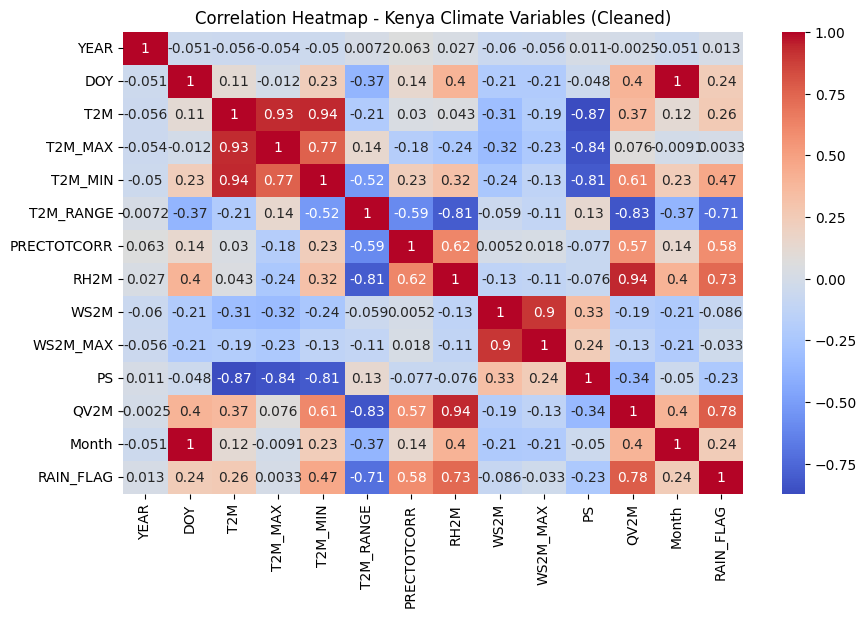

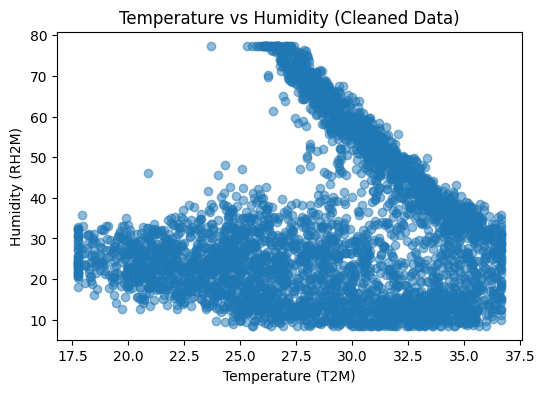

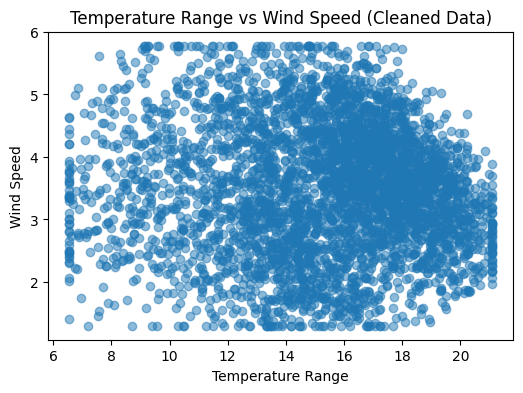

In [ ]:


# Correlation heatmap
import seaborn as sns
import matplotlib.pyplot as plt

# Correlation heatmap (CLEANED DATA)
plt.figure(figsize=(10,6))
sns.heatmap(df_cleaned.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap - sudan Climate Variables (Cleaned)")
plt.show()

# Scatter plot
plt.figure(figsize=(6,4))
plt.scatter(df_cleaned["T2M"], df_cleaned["RH2M"], alpha=0.5)
plt.xlabel("Temperature (T2M)")
plt.ylabel("Humidity (RH2M)")
plt.title("Temperature vs Humidity (Cleaned Data)")
plt.show()

plt.figure(figsize=(6,4))
plt.scatter(df_cleaned["T2M_RANGE"], df_cleaned["WS2M"], alpha=0.5)
plt.xlabel("Temperature Range")
plt.ylabel("Wind Speed")
plt.title("Temperature Range vs Wind Speed (Cleaned Data)")
plt.show()

In [16]:
df_cleaned["PRECTOTCORR"].describe()

count    4108.000000
mean        0.193506
std         0.539616
min         0.000000
25%         0.000000
50%         0.000000
75%         0.009950
max         3.736395
Name: PRECTOTCORR, dtype: float64

After transformation, rainfall values are compressed (max reduced to ~3.74, std to ~0.54), making the feature more stable and suitable for modeling.

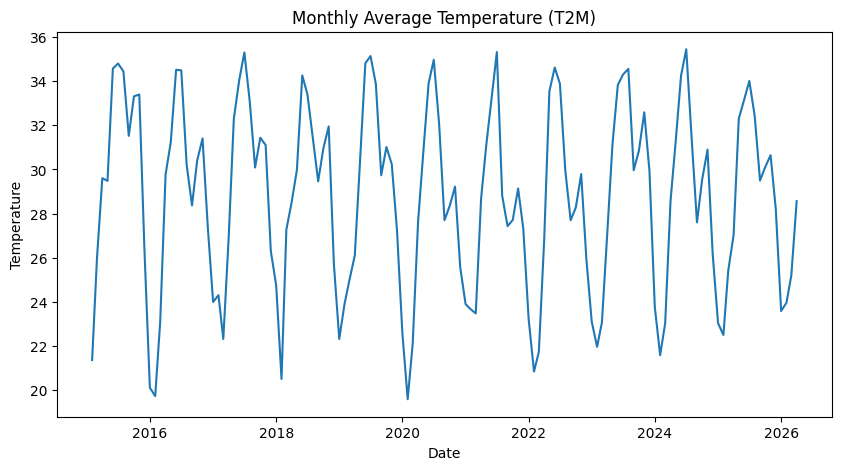

In [17]:
#T2m
import matplotlib.pyplot as plt

# ensure datetime
df_cleaned["Date"] = pd.to_datetime(df_cleaned["Date"])

# set index for resampling
df_ts = df_cleaned.set_index("Date")

# monthly average temperature
monthly_temp = df_ts["T2M"].resample("ME").mean()

plt.figure(figsize=(10,5))
plt.plot(monthly_temp)
plt.title("Monthly Average Temperature (T2M)")
plt.xlabel("Date")
plt.ylabel("Temperature")
plt.show()

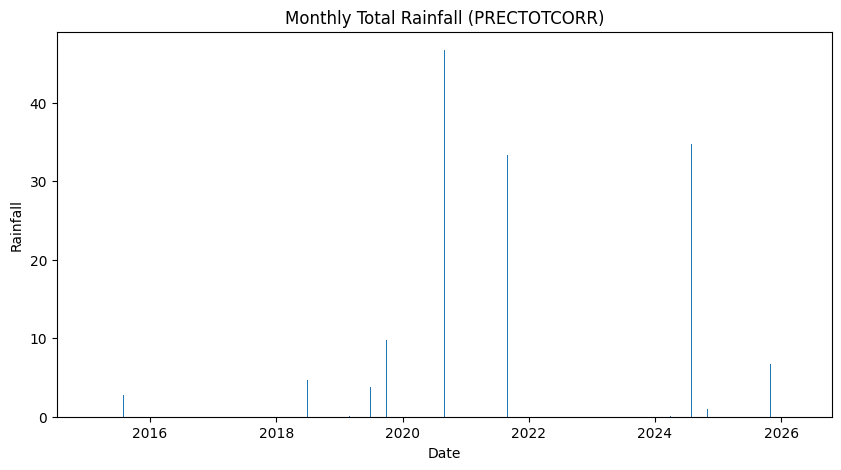

In [18]:
# Rain fall
monthly_rain = df_ts["PRECTOTCORR"].resample("ME").sum()

plt.figure(figsize=(10,5))
plt.bar(monthly_rain.index, monthly_rain)
plt.title("Monthly Total Rainfall (PRECTOTCORR)")
plt.xlabel("Date")
plt.ylabel("Rainfall")
plt.show()

In [19]:
# cleaned correlation
corr = df_cleaned.corr(numeric_only=True)

# unstack and sort correlations
corr_pairs = corr.unstack().sort_values(ascending=False)

# remove self-correlation
corr_pairs = corr_pairs[corr_pairs < 1]

print("Top Correlations:")
print(corr_pairs.head(10))

Top Correlations:
DOY       Month       0.996557
Month     DOY         0.996557
T2M       T2M_MIN     0.941470
T2M_MIN   T2M         0.941470
QV2M      RH2M        0.935771
RH2M      QV2M        0.935771
T2M       T2M_MAX     0.933708
T2M_MAX   T2M         0.933708
WS2M_MAX  WS2M        0.900725
WS2M      WS2M_MAX    0.900725
dtype: float64


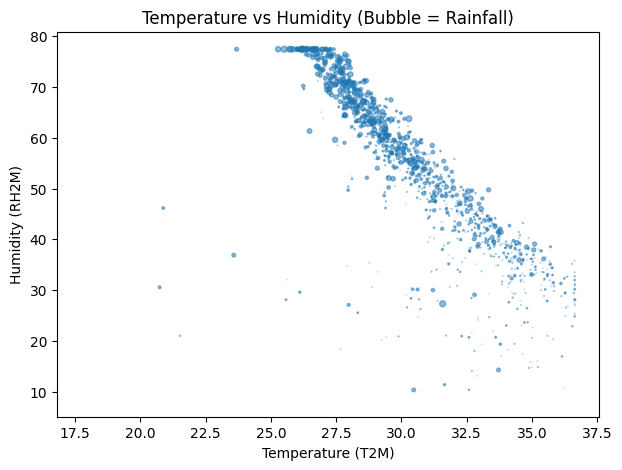

In [20]:
# bubble
plt.figure(figsize=(7,5))

plt.scatter(
    df_cleaned["T2M"],
    df_cleaned["RH2M"],
    s=df_cleaned["PRECTOTCORR"] * 5,
    alpha=0.5
)

plt.title("Temperature vs Humidity (Bubble = Rainfall)")
plt.xlabel("Temperature (T2M)")
plt.ylabel("Humidity (RH2M)")
plt.show()